[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/camiloandcu/Retail-Demand-Forecasting/blob/main/01_data_audit_eda.ipynb)

# 01 - Data acquisition, validation, and exploration

**Purpose.** Acquire the competition files, verify their integrity and schema, and identify data properties that affect a 16-day forecast. No model is trained here.

**Inputs:** `configs/full.yaml`, seven Kaggle CSV files, and the reusable `retail_forecast` package. Set the environment variable `RETAIL_FORECAST_MODE=smoke` to use deterministic schema-only fixtures.

**Outputs:** `artifacts/metrics/eda_summary.json`, `artifacts/metrics/dataset_manifest.json`, and up to nine PNG files under `artifacts/figures/eda/`. Raw files are never modified.

## Reading guide

Each figure is followed by a plain-language reading of the verified full-data pattern and its concrete consequence for later development. The plotting cell prints the values measured in the current run. Smoke mode validates execution with synthetic data, so its numbers and figures are not project findings. All sales analysis uses `train.csv`; test targets do not exist and no random split is used.

In [ ]:
# Clone only when the notebook is opened in a fresh Colab runtime.
import importlib.util
import os
import shutil
import subprocess
import sys
from getpass import getpass
from pathlib import Path

REPO_URL = "https://github.com/camiloandcu/Retail-Demand-Forecasting.git"
BRANCH = "main" 
IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    REPO_ROOT = Path("/content/Retail-Demand-Forecasting")
    if not (REPO_ROOT / "pyproject.toml").is_file():
        subprocess.run(
            [
                "git",
                "clone",
                "--branch",
                BRANCH,
                "--single-branch",
                "--depth",
                "1",
                REPO_URL,
                str(REPO_ROOT),
            ],
            check=True,
        )
    else:
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "fetch", "--depth", "1", "origin", BRANCH],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
else:
    REPO_ROOT = Path.cwd().resolve()
    if not (REPO_ROOT / "pyproject.toml").is_file():
        raise RuntimeError("Run the notebook from the repository root.")

os.chdir(REPO_ROOT)
if importlib.util.find_spec("pip") is not None:
    install_command = [sys.executable, "-m", "pip", "install", "-e", ".[notebook]"]
elif shutil.which("uv"):
    install_command = ["uv", "pip", "install", "--python", sys.executable, "-e", ".[notebook]"]
else:
    raise RuntimeError("This environment provides neither pip nor uv.")
subprocess.run(install_command, check=True)
source_path = str(REPO_ROOT / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)
importlib.invalidate_caches()
if importlib.util.find_spec("retail_forecast") is None:
    raise RuntimeError("retail_forecast was installed but is not importable.")
print(f"Repository ready at {REPO_ROOT} with Python {sys.version.split()[0]}")

Resolved 114 packages in 279ms
   Building retail-forecast @ file:///home/camilo/projects/eco-forecasting


Repository ready at /home/camilo/projects/eco-forecasting with Python 3.10.12


      Built retail-forecast @ file:///home/camilo/projects/eco-forecasting
Prepared 1 package in 4.01s
Uninstalled 1 package in 6ms
Installed 1 package in 3ms
 ~ retail-forecast==0.1.0 (from file:///home/camilo/projects/eco-forecasting)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from retail_forecast import __version__
from retail_forecast.acquisition import acquire_competition_data
from retail_forecast.config import load_config
from retail_forecast.data import required_files_exist, validate_dataset, write_synthetic_dataset
from retail_forecast.eda import (
    build_eda_summary,
    build_eda_tables,
    build_manifest,
    export_eda_artifacts,
    load_eda_frames,
    save_figure,
    validate_kaggle_hashes,
)
from retail_forecast.logging_utils import configure_logging
from retail_forecast.reproducibility import set_global_seed
from retail_forecast.versions import capture_versions

MODE = os.getenv("RETAIL_FORECAST_MODE", "full").strip().lower()
if MODE not in {"full", "smoke"}:
    raise ValueError("RETAIL_FORECAST_MODE must be 'full' or 'smoke'.")
config = load_config(f"configs/{MODE}.yaml")
configure_logging(config.runtime.log_level)
set_global_seed(config.runtime.seed)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.titleweight": "bold"})
print(f"mode={MODE} | package={__version__} | horizon={config.forecast.horizon}")
display(capture_versions())

mode=full | package=0.1.0 | horizon=16


{'python': '3.10.12',
 'platform': 'Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.35',
 'packages': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'PyYAML': '6.0.3',
  'retail-forecast': '0.1.0',
  'lightgbm': '4.7.0',
  'scikit-learn': '1.7.2',
  'tensorflow': None,
  'mlflow': '3.16.0'}}

## Get the competition data

Existing CSVs and a locally available competition ZIP are reused automatically. If neither is present, the next cell asks for a Kaggle API token using hidden input. Press Enter without a token to see the accepted local paths.

In [3]:
if config.data.source == "synthetic":
    if not required_files_exist(config.paths.raw_data_dir):
        write_synthetic_dataset(config)
elif not required_files_exist(config.paths.raw_data_dir):
    acquire_competition_data(
        config.paths.raw_data_dir,
        (REPO_ROOT / "data", REPO_ROOT),
        token_reader=getpass,
    )

hashes = validate_kaggle_hashes(config.paths.raw_data_dir) if MODE == "full" else {}
dataset_contract = validate_dataset(config)
print("Acquisition and integrity checks: PASS")
display(dataset_contract.to_dict())

Acquisition and integrity checks: PASS


{'train_rows': 3000888,
 'test_rows': 28512,
 'stores': 54,
 'families': 33,
 'series': 1782,
 'train_start': '2013-01-01',
 'train_end': '2017-08-15',
 'test_start': '2017-08-16',
 'test_end': '2017-08-31',
 'horizon': 16,
 'source': 'kaggle'}

In [4]:
frames = load_eda_frames(config.paths.raw_data_dir)
manifest = build_manifest(config.paths.raw_data_dir, frames)
tables = build_eda_tables(frames)
eda_summary = build_eda_summary(frames, tables, config.data.source)

METRICS_DIR = REPO_ROOT / "artifacts/metrics"
FIGURES_DIR = REPO_ROOT / "artifacts/figures/eda"
summary_path, manifest_path = export_eda_artifacts(eda_summary, manifest, METRICS_DIR)
manifest_view = pd.DataFrame(
    [
        {
            "file": filename,
            "bytes": values["bytes"],
            "rows": values["rows"],
            "columns": len(values["columns"]),
            "missing": sum(values["missing"].values()),
            "date_min": values.get("date_min"),
            "date_max": values.get("date_max"),
        }
        for filename, values in manifest.items()
    ]
)
display(manifest_view)
print(f"Detailed dtypes and missingness exported to {manifest_path}")

,file,bytes,rows,columns,missing,date_min,date_max
0,train.csv,121800373,3000888,6,0,2013-01-01,2017-08-15
1,test.csv,1022269,28512,5,0,2017-08-16,2017-08-31
2,sample_submission.csv,342153,28512,2,0,None,None
3,stores.csv,1387,54,5,0,None,None
4,oil.csv,20580,1218,2,43,2013-01-01,2017-08-31
5,holidays_events.csv,22309,350,6,0,2012-03-02,2017-12-26
6,transactions.csv,1552637,83488,3,0,2013-01-01,2017-08-15


Detailed dtypes and missingness exported to /home/camilo/projects/eco-forecasting/artifacts/metrics/dataset_manifest.json


## Question 1 - How does total demand evolve over time, and is there evidence of level changes?

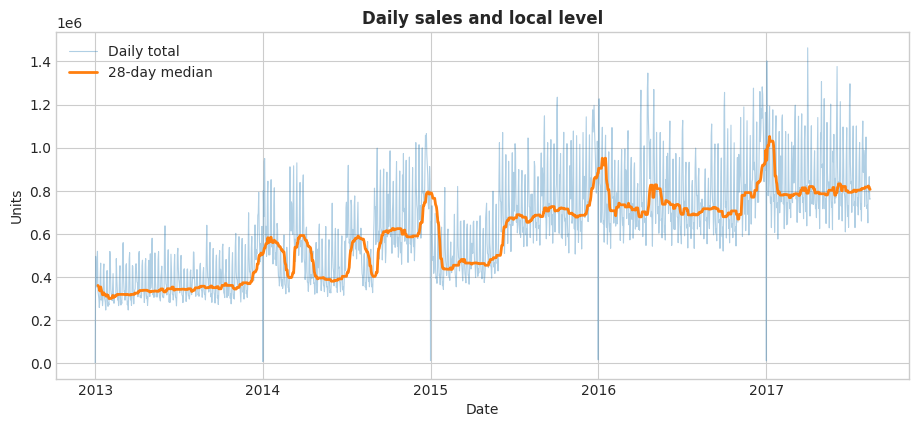

Last 90 days / first 90 days mean-sales ratio: 2.451x


In [5]:
daily = tables["daily_sales"]
fig, ax = plt.subplots()
ax.plot(daily["date"], daily["sales"], alpha=0.35, linewidth=0.8, label="Daily total")
ax.plot(daily["date"], daily["rolling_28d"], linewidth=2, label="28-day median")
ax.set(title="Daily sales and local level", xlabel="Date", ylabel="Units")
ax.legend()
save_figure(fig, FIGURES_DIR, "01_daily_sales.png")
plt.show()

level_ratio = eda_summary["observations"]["last_to_first_90d_ratio"]
print(f"Last 90 days / first 90 days mean-sales ratio: {level_ratio:.3f}x")

### What the chart says

Demand does not fluctuate around one stable level. The 28-day median rises over the history and is interrupted by recurring peaks and abrupt changes. The ratio printed above quantifies how different the end of the series is from its beginning.

**What this changes:** validation must move forward through time, and features should emphasize recent lags and rolling windows. Any learned scaling or aggregation belongs inside each training fold so later demand levels cannot influence earlier forecasts.

## Question 2 - How many zeros and extreme values does the target contain?

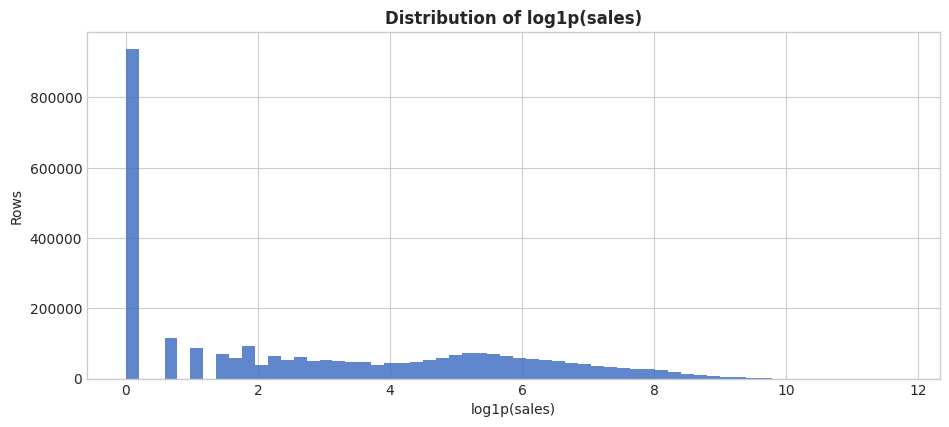

,Measured value
Zero-sales rows,31.30%
Rows above the IQR rule,"447,105"
Fractional-sales rows,"462,113"
Median sales,11.00
99th percentile,"5,507.00"
Maximum,"124,717.00"


In [6]:
sales = frames["train.csv"]["sales"]
fig, ax = plt.subplots()
ax.hist(np.log1p(sales), bins=60, color="#4472C4", alpha=0.85)
ax.set(title="Distribution of log1p(sales)", xlabel="log1p(sales)", ylabel="Rows")
save_figure(fig, FIGURES_DIR, "02_sales_distribution.png")
plt.show()

target_stats = eda_summary["observations"]
display(
    pd.Series(
        {
            "Zero-sales rows": f"{target_stats['zero_sales_rate']:.2%}",
            "Rows above the IQR rule": f"{target_stats['iqr_outlier_candidates']:,}",
            "Fractional-sales rows": f"{target_stats['fractional_sales_rows']:,}",
            "Median sales": f"{target_stats['sales_quantiles']['0.5']:,.2f}",
            "99th percentile": f"{target_stats['sales_quantiles']['0.99']:,.2f}",
            "Maximum": f"{target_stats['sales_quantiles']['1.0']:,.2f}",
        },
        name="Measured value",
    ).to_frame()
)

### What the chart says

The target combines a large mass at zero with several positive-sales scales and a long upper tail. Values flagged by the IQR rule are too common to treat as automatic data errors, and fractional sales confirm that this is a non-negative continuous target rather than a simple item count.

**What this changes:** keep genuine zeros and large observations, optimize on a `log1p`-compatible scale, clip predictions at zero, and inspect errors by store and family instead of relying only on one aggregate score.

## Question 3 - How uneven is demand across stores?

2026-09-16T16:37:35 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-16T16:37:35 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


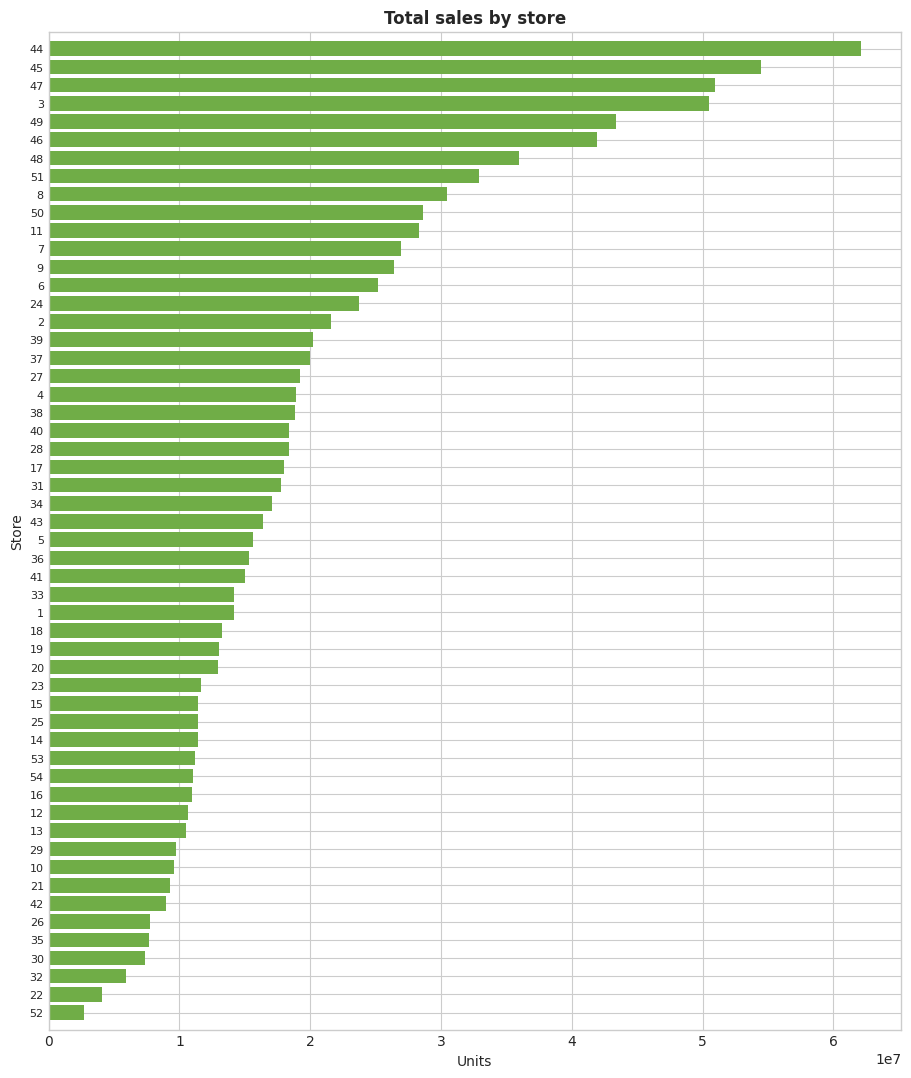

,Measured value
Largest cumulative-sales store,44
Smallest cumulative-sales store,52
Largest / smallest total,23.03x


In [7]:
store_sales = tables["store_sales"].sort_values("sales")
figure_height = max(5.0, 0.24 * len(store_sales))
fig, ax = plt.subplots(figsize=(11, figure_height))
ax.barh(store_sales["store_nbr"].astype(str), store_sales["sales"], color="#70AD47")
ax.set(title="Total sales by store", xlabel="Units", ylabel="Store")
ax.tick_params(axis="y", labelsize=8)
ax.margins(y=0.01)
save_figure(fig, FIGURES_DIR, "03_store_sales.png")
plt.show()

smallest_store = store_sales.iloc[0]
largest_store = store_sales.iloc[-1]
store_ratio = largest_store["sales"] / max(smallest_store["sales"], 1e-12)
display(
    pd.Series(
        {
            "Largest cumulative-sales store": int(largest_store["store_nbr"]),
            "Smallest cumulative-sales store": int(smallest_store["store_nbr"]),
            "Largest / smallest total": f"{store_ratio:.2f}x",
        },
        name="Measured value",
    ).to_frame()
)

### What the chart says

Store volume is highly uneven: a few locations account for much more cumulative demand than the long lower-volume tail. These totals also reflect how long each store was active, so they should not be read as a pure comparison of daily demand.

**What this changes:** retain store identity and metadata, build lags at store-family level, and report store-level validation results. A later diagnostic should compare sales per active day before attributing the full gap to store characteristics.

## Question 4 - Which families dominate sales, and where are zeros concentrated?

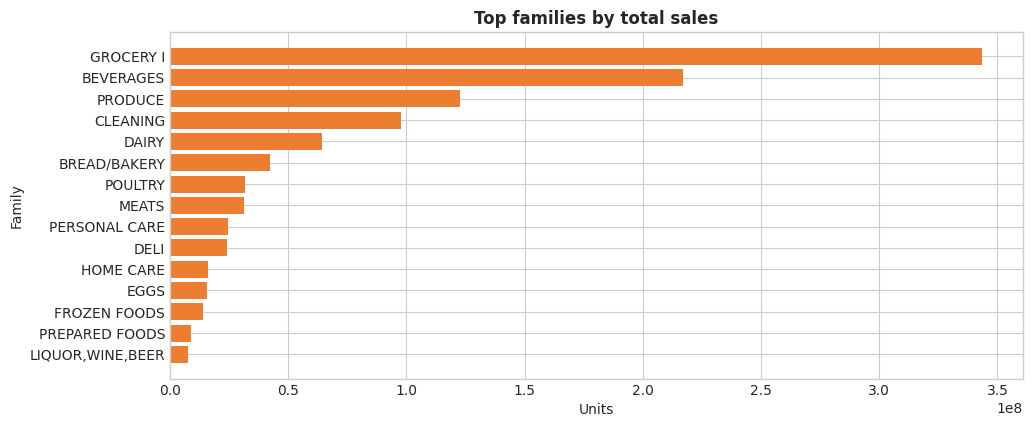

,Measured value
Largest cumulative-sales family,GROCERY I
Highest-zero family,BOOKS
Highest family zero rate,96.96%


In [8]:
family_sales = tables["family_sales"].head(15).sort_values("sales")
fig, ax = plt.subplots()
ax.barh(family_sales["family"], family_sales["sales"], color="#ED7D31")
ax.set(title="Top families by total sales", xlabel="Units", ylabel="Family")
save_figure(fig, FIGURES_DIR, "04_family_sales.png")
plt.show()

all_family = tables["family_sales"]
top_family = all_family.iloc[0]
highest_zero = all_family.sort_values("zero_rate", ascending=False).iloc[0]
display(
    pd.Series(
        {
            "Largest cumulative-sales family": top_family["family"],
            "Highest-zero family": highest_zero["family"],
            "Highest family zero rate": f"{highest_zero['zero_rate']:.2%}",
        },
        name="Measured value",
    ).to_frame()
)

### What the chart says

A small group of families dominates total volume, while some families are mostly zero. The printed values connect both ends of that problem: the volume leader and the family with the most intermittent history are not interchangeable forecasting cases.

**What this changes:** preserve family identity, allow store-family interactions, and report family-level RMSLE. Model selection must not improve dominant families while silently failing on sparse ones.

## Question 5 - Are promoted rows associated with different sales and zero rates?

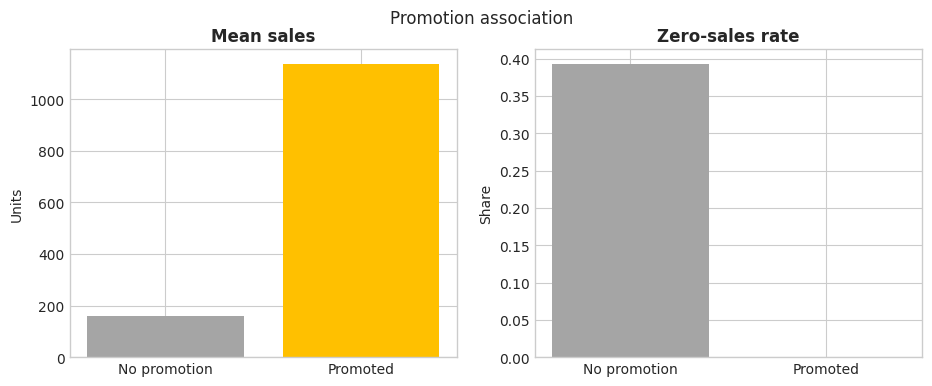

,rows,mean_sales,median_sales,zero_rate
group,,,,
No promotion,"2,389,559",158.25,3.00,39.30%
Promoted,"611,329","1,137.69",373.00,0.00%


Promoted / non-promoted mean-sales ratio: 7.19x


In [9]:
promotion = tables["promotion"].copy()
labels = promotion["promoted"].map({False: "No promotion", True: "Promoted"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels, promotion["mean_sales"], color=["#A5A5A5", "#FFC000"])
axes[0].set(title="Mean sales", ylabel="Units")
axes[1].bar(labels, promotion["zero_rate"], color=["#A5A5A5", "#FFC000"])
axes[1].set(title="Zero-sales rate", ylabel="Share")
fig.suptitle("Promotion association")
save_figure(fig, FIGURES_DIR, "05_promotions.png")
plt.show()

promotion_view = promotion.assign(group=labels).set_index("group")
promotion_ratio = promotion_view.loc["Promoted", "mean_sales"] / max(
    promotion_view.loc["No promotion", "mean_sales"], 1e-12
)
promotion_metrics = promotion_view[["rows", "mean_sales", "median_sales", "zero_rate"]].copy()
promotion_metrics["rows"] = promotion_metrics["rows"].map(lambda value: f"{value:,.0f}")
promotion_metrics["mean_sales"] = promotion_metrics["mean_sales"].map(lambda value: f"{value:,.2f}")
promotion_metrics["median_sales"] = promotion_metrics["median_sales"].map(
    lambda value: f"{value:,.2f}"
)
promotion_metrics["zero_rate"] = promotion_metrics["zero_rate"].map(lambda value: f"{value:.2%}")
display(promotion_metrics)
print(f"Promoted / non-promoted mean-sales ratio: {promotion_ratio:.2f}x")

### What the chart says

Promoted rows occupy a very different sales regime: their average is much higher and their zero-sales share is much lower. This comparison is descriptive, because promotions are not assigned randomly and the promoted assortment differs across stores, families, and dates.

**What this changes:** use the future `onpromotion` values supplied in `test.csv`, retain both count and binary representations, and test store-family-promotion interactions. Judge its forecasting contribution through rolling-origin ablation rather than treating the ratio as causal lift.

## Question 6 - Do daily transaction counts move with aggregate sales?

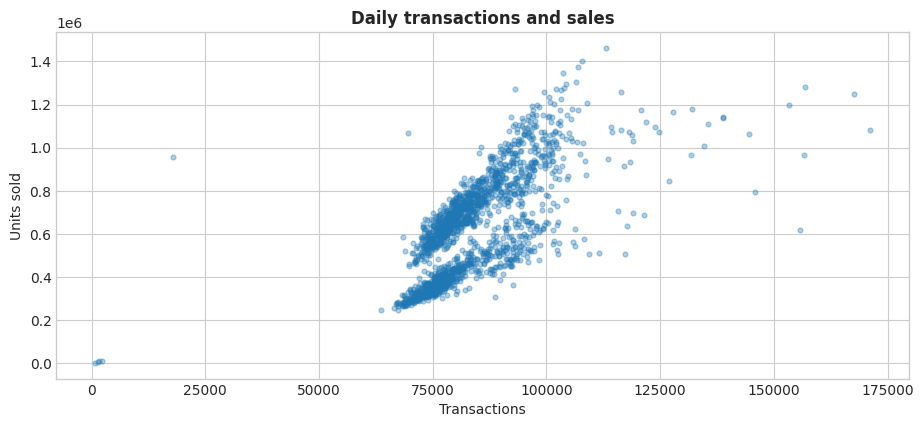

Aggregate Pearson correlation: 0.677
Transaction store-date coverage: 91.81%


In [10]:
sales_transactions = tables["sales_transactions"]
fig, ax = plt.subplots()
ax.scatter(sales_transactions["transactions"], sales_transactions["sales"], s=12, alpha=0.35)
ax.set(title="Daily transactions and sales", xlabel="Transactions", ylabel="Units sold")
save_figure(fig, FIGURES_DIR, "06_transactions.png")
plt.show()

transaction_correlation = sales_transactions[["transactions", "sales"]].corr().iloc[0, 1]
transaction_coverage = eda_summary["observations"]["transaction_store_date_coverage"]
print(f"Aggregate Pearson correlation: {transaction_correlation:.3f}")
print(f"Transaction store-date coverage: {transaction_coverage:.2%}")

### What the chart says

Days with more transactions generally have more units sold, but the scatter separates into visible bands rather than one stable relationship. Coverage is incomplete, so a missing transaction row cannot be interpreted as a day with no transactions.

**What this changes:** future transactions are unavailable and must never enter a forecast directly. Only causal lags and rolling windows are eligible, accompanied by a missingness indicator and tested for value beyond sales-history features.

## Question 7 - Is oil price associated with aggregate sales over the training period?

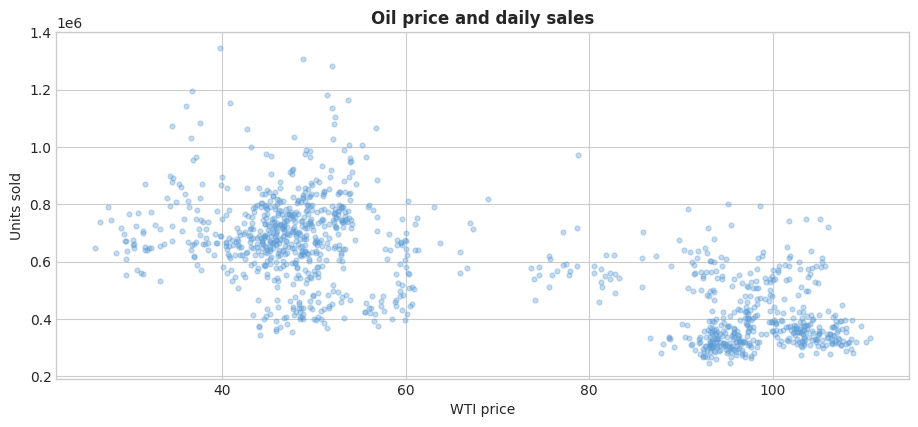

Contemporaneous aggregate Pearson correlation: -0.705
Missing oil values: 43


In [11]:
oil_sales = tables["oil_sales"].dropna(subset=["dcoilwtico"])
fig, ax = plt.subplots()
ax.scatter(oil_sales["dcoilwtico"], oil_sales["sales"], s=12, alpha=0.35, color="#5B9BD5")
ax.set(title="Oil price and daily sales", xlabel="WTI price", ylabel="Units sold")
save_figure(fig, FIGURES_DIR, "07_oil.png")
plt.show()

oil_correlation = oil_sales[["dcoilwtico", "sales"]].corr().iloc[0, 1]
oil_missing = eda_summary["observations"]["oil_missing_values"]
print(f"Contemporaneous aggregate Pearson correlation: {oil_correlation:.3f}")
print(f"Missing oil values: {oil_missing:,}")

### What the chart says

Oil price and aggregate sales move in opposite directions in this historical sample, but the points form time-like clusters instead of one stable linear cloud. The coefficient therefore mixes oil variation with the strong sales-level changes already visible in Question 1.

**What this changes:** use only oil values supplied for the forecast dates, preserve missingness, and fit imputation inside each fold. Oil remains an optional feature whose value must be demonstrated by rolling-origin ablation.

## Question 8 - What holiday/event types exist, and can a date-only join be trusted?

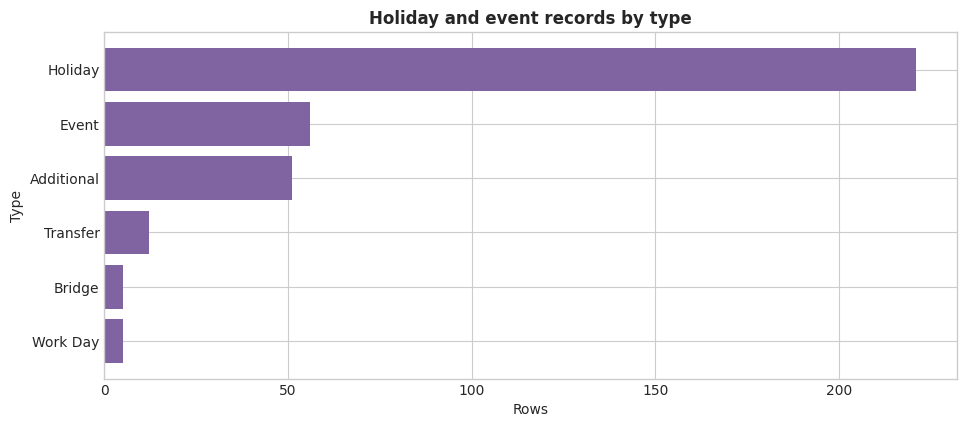

Holiday rows on duplicated dates: 69


In [12]:
holiday_types = tables["holiday_types"].sort_values("size")
fig, ax = plt.subplots()
ax.barh(holiday_types["type"], holiday_types["size"], color="#8064A2")
ax.set(title="Holiday and event records by type", xlabel="Rows", ylabel="Type")
save_figure(fig, FIGURES_DIR, "08_holidays.png")
plt.show()

duplicate_holiday_rows = eda_summary["observations"]["holiday_duplicate_date_rows"]
print(f"Holiday rows on duplicated dates: {duplicate_holiday_rows:,}")

### What the chart says

Regular holidays dominate the file, but events, additional holidays, transfers, bridges, and work days all carry different calendar meanings. Multiple records can share a date, so the source is not a unique date lookup table.

**What this changes:** resolve national, regional, and local scope for each store; interpret transfers and compensating work days; then aggregate to one store-date feature row. The join must be tested to prove that it never multiplies sales rows.

## Question 9 - What weekly, monthly, and annual seasonal structure is visible using train only?

2026-09-16T16:37:38 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-16T16:37:38 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-16T16:37:38 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-16T16:37:38 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


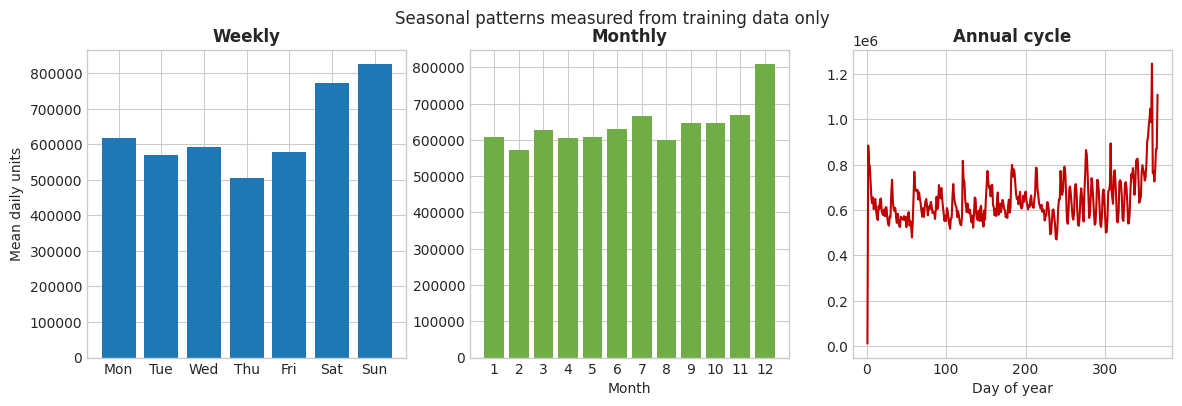

Highest mean-sales weekday: Sun
Highest mean-sales month: 12
Highest mean-sales day of year: 359


In [13]:
weekday = tables["weekday"]
month = tables["month"]
annual_cycle = tables["annual_cycle"]
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar([weekday_names[int(value)] for value in weekday["weekday"]], weekday["sales"])
axes[0].set(title="Weekly", ylabel="Mean daily units")
axes[1].bar(month["month"].astype(str), month["sales"], color="#70AD47")
axes[1].set(title="Monthly", xlabel="Month")
axes[2].plot(annual_cycle["dayofyear"], annual_cycle["sales"], color="#C00000")
axes[2].set(title="Annual cycle", xlabel="Day of year")
fig.suptitle("Seasonal patterns measured from training data only")
save_figure(fig, FIGURES_DIR, "09_seasonality.png")
plt.show()

best_weekday = weekday.loc[weekday["sales"].idxmax(), "weekday"]
best_month = month.loc[month["sales"].idxmax(), "month"]
best_annual_day = annual_cycle.loc[annual_cycle["sales"].idxmax(), "dayofyear"]
print(f"Highest mean-sales weekday: {weekday_names[int(best_weekday)]}")
print(f"Highest mean-sales month: {int(best_month)}")
print(f"Highest mean-sales day of year: {int(best_annual_day)}")

### What the chart says

The weekly profile is strongest on the weekend, December stands above the other months, and the annual view contains a sharp year-end peak. Raw day-of-year averages need care because leap years shift ordinal dates, Christmas is absent from training, and 2017 ends in August.

**What this changes:** retain weekday and month signals, encode year-end events explicitly, and prefer aligned month/day or cyclical terms over memorizing a raw day-of-year maximum. Learned seasonal aggregates must remain inside each temporal fold.

## Final checks and model-design consequences

In [14]:
final_manifest = build_manifest(config.paths.raw_data_dir, frames)
raw_unchanged = all(manifest[name]["sha256"] == final_manifest[name]["sha256"] for name in manifest)
figure_files = sorted(FIGURES_DIR.glob("*.png"))
checks = {
    "16-day horizon": dataset_contract.horizon == 16,
    "seven schemas loaded": len(frames) == 7,
    "Kaggle hashes verified or synthetic mode": MODE == "smoke" or len(hashes) == 7,
    "raw files unchanged during EDA": raw_unchanged,
    "EDA summary exported": summary_path.is_file(),
    "dataset manifest exported": manifest_path.is_file(),
    "figure limit respected": 0 < len(figure_files) <= 10,
    "future transactions absent": frames["transactions.csv"]["date"].max()
    <= frames["train.csv"]["date"].max(),
}
check_table = pd.DataFrame(
    [{"check": name, "status": "PASS" if passed else "FAIL"} for name, passed in checks.items()]
)
display(check_table)
if not all(checks.values()):
    raise AssertionError(
        f"EDA checks failed: {[name for name, passed in checks.items() if not passed]}"
    )
print(f"PASS: {len(checks)} checks; {len(figure_files)} figures; raw inputs unchanged.")
display(
    pd.Series(
        {
            "Mode": MODE,
            "Training rows": f"{dataset_contract.train_rows:,}",
            "Test rows": f"{dataset_contract.test_rows:,}",
            "Store-family series": f"{dataset_contract.series:,}",
            "Forecast horizon": f"{dataset_contract.horizon} days",
            "Missing training dates": len(eda_summary["observations"]["missing_calendar_dates"]),
        },
        name="Run result",
    ).to_frame()
)
print(f"Artifacts ready: {summary_path} and {FIGURES_DIR}")

,check,status
0,16-day horizon,PASS
1,seven schemas loaded,PASS
2,Kaggle hashes verified or synthetic mode,PASS
3,raw files unchanged during EDA,PASS
4,EDA summary exported,PASS
5,dataset manifest exported,PASS
6,figure limit respected,PASS
7,future transactions absent,PASS


PASS: 8 checks; 9 figures; raw inputs unchanged.


,Run result
Mode,full
Training rows,"3,000,888"
Test rows,"28,512"
Store-family series,"1,782"
Forecast horizon,16 days
Missing training dates,4


Artifacts ready: /home/camilo/projects/eco-forecasting/artifacts/metrics/eda_summary.json and /home/camilo/projects/eco-forecasting/artifacts/figures/eda


### Where this leaves the forecasting pipeline

The data is suitable for a 16-day store-family forecast, but it combines non-stationary demand, many zeros, large scale differences, promotions, sparse auxiliary variables, and calendar records that require store-aware resolution. The next stages therefore need: 

- rolling-origin folds with the same 16-day horizon as Kaggle;
- a weekly seasonal-naive reference;
- causal store-family lags and rolling windows;
- fold-fitted preprocessing and explicit missingness;
- carefully resolved promotion, oil, transaction, and holiday availability; and
- RMSLE reported overall and by horizon, store, and family.

These are development constraints derived from the measured dataset, not claims that any untested feature or model will improve accuracy.